In [22]:
from GTSRB import GTSRB_Wrapper

# 1. Get the Black Square Dataset (Mix for training)
train_set = GTSRB_Wrapper(mode='train', poison_type='black_1', poison_rate=0.1)

# --- find poisoned indices in the mixed training set (ground-truth for evaluation of defense) ---
poisoned_location = set()
for i in range(len(train_set)):
    _, _, is_p = train_set[i]
    if int(is_p) == 1:
        poisoned_location.add(i)

print(f">>> Poisoned samples in train_set: {len(poisoned_location)} / {len(train_set)}")


# 2. Get the Green Dataset (100% Poisoned for ASR)
test_poison_green = GTSRB_Wrapper(mode='test', poison_type='green_1', poison_rate=1.0)

# 3. Get Clean Dataset (0% Poisoned)
test_clean = GTSRB_Wrapper(mode='test', poison_type='black_1', poison_rate=0.0)

>>> Poisoned samples in train_set: 3958 / 39209


In [2]:
import torch
print("torch:", torch.__version__)
print("cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

torch: 2.10.0+cu128
cuda build: 12.8
cuda available: True
device count: 1
gpu: NVIDIA GeForce RTX 3090


In [12]:
import sys
import os

# Add the 'BackdoorBox' folder to the python path
sys.path.append(os.path.join(os.getcwd(), '..'))

# Now you can import core as if you were inside the folder
from BackdoorBox.core.defenses import AutoEncoderDefense, Spectral

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import numpy as np

from GTSRB import GTSRB_Wrapper
from torchvision.models import resnet18 

# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LR = 0.01
EPOCHS = 15
TARGET_LABEL = 5 # Speed Limit 80
POISON_TYPE = 'black_1' 
ROOT_DIR = '../data' # Adjust if needed

print(f"Running Final Experiment on {DEVICE}")

# --- DATA ---
# transform = transforms.Compose([
#     transforms.Resize((32, 32)),
#     transforms.ToTensor()
# ])
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

print(">>> Loading Data...")
# Train set (Mixed)
train_set = GTSRB_Wrapper(root_dir=ROOT_DIR, mode='train', poison_type=POISON_TYPE, poison_rate=0.01, transform=transform, target_label=TARGET_LABEL)
# Test set Clean
test_clean = GTSRB_Wrapper(root_dir=ROOT_DIR, mode='test', poison_type=POISON_TYPE, poison_rate=0.0, transform=transform, target_label=TARGET_LABEL)
# Test set Poison
test_poison = GTSRB_Wrapper(root_dir=ROOT_DIR, mode='test', poison_type=POISON_TYPE, poison_rate=1.0, transform=transform, target_label=TARGET_LABEL)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader_clean = DataLoader(test_clean, batch_size=BATCH_SIZE)
test_loader_poison = DataLoader(test_poison, batch_size=BATCH_SIZE)


# --- find poisoned indices in the mixed training set (ground-truth for evaluation of defense) ---
poisoned_location = set()
for i in range(len(train_set)):
    _, _, is_p = train_set[i]
    if int(is_p) == 1:
        poisoned_location.add(i)

print(f">>> Poisoned samples in train_set: {len(poisoned_location)} / {len(train_set)}")


import torch.nn as nn
from torchvision.models import resnet18

def resnet18_cifar(num_classes=43):
    m = resnet18(num_classes=num_classes)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m


# --- HELPER ---
def eval_net(model, name):
    model.eval()
    # Clean Acc
    corr = 0
    tot = 0
    with torch.no_grad():
        for x, y, _ in test_loader_clean:
            x, y = x.to(DEVICE), y.to(DEVICE)
            _, pred = torch.max(model(x), 1)
            corr += (pred == y).sum().item()
            tot += y.size(0)
    acc = 100 * corr / tot
    
    # ASR
    corr_p = 0
    tot_p = 0
    with torch.no_grad():
        for x, y, _ in test_loader_poison:
            x, y = x.to(DEVICE), y.to(DEVICE)
            _, pred = torch.max(model(x), 1)
            corr_p += (pred == y).sum().item()
            tot_p += y.size(0)
    asr = 100 * corr_p / tot_p if tot_p > 0 else 0
    
    print(f"[{name}] Clean Acc: {acc:.2f}% | ASR: {asr:.2f}%")
    return acc, asr




Running Final Experiment on cuda
>>> Loading Data...
>>> Poisoned samples in train_set: 394 / 39209


In [18]:

# ================= PHASE 1: BADNET =================
print("\n>>> Phase 1: Training BadNet...")
# badnet = resnet18_cifar(num_classes=43).to(DEVICE)
badnet = resnet18(num_classes=43).to(DEVICE)
# ResNet18 expects standard conv1. We fit it to 32x32 by replacing first layer if needed, 
# but for 32x32 input standard ResNet is okay-ish, or we can use small-kernel modification.
# Standard is fine for this exercise.
opt = optim.SGD(badnet.parameters(), lr=LR, momentum=0.9)
crit = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    badnet.train()
    loss_tot = 0
    for x, y, _ in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        loss = crit(badnet(x), y)
        loss.backward()
        opt.step()
        loss_tot += loss.item()
    if (epoch+1)%5==0: print(f"Epoch {epoch+1} Loss: {loss_tot/len(train_loader):.5f}")

eval_net(badnet, "Baseline")


>>> Phase 1: Training BadNet...
Epoch 5 Loss: 0.04089
Epoch 10 Loss: 0.00790
Epoch 15 Loss: 0.00117
[Baseline] Clean Acc: 92.30% | ASR: 63.38%


(92.29612034837687, 63.38083927157562)

In [20]:
# ================= PHASE 2: SPECTRAL FILTER =================
print("\n>>> Phase 2: Running Spectral Signatures defense...")

# Import BackdoorBox defense (adjust import path depending on your installation)
from BackdoorBox.core.defenses.Spectral import Spectral

schedule = {
    "device": "GPU" if torch.cuda.is_available() else "CPU",
    "GPU_num": 1,
    # optionally: "CUDA_VISIBLE_DEVICES": "0",
}

spectral = Spectral(
    model=badnet,                    # use the already-trained poisoned model
    loss=crit,
    seed=0,
    target_label=TARGET_LABEL,       # must match the dirty-label target
    percentile=80,                   # you will likely tune 80..95
    poisoned_trainset=train_set,     # can be your wrapper; Spectral uses [0] and [1]
)

removed_global, kept_global = spectral.filter(schedule)

T = set(i for i in range(len(train_set)) if int(train_set[i][1]) == 5)
P = poisoned_location & T
Pred = set(removed_global.tolist())

tp = len(Pred & P)
fp = len(Pred - P)
fn = len(P - Pred)
tn = len(T) - tp - fp - fn

precision = tp / (tp + fp + 1e-12)
recall = tp / (tp + fn + 1e-12)

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")



>>> Phase 2: Running Spectral Signatures defense...
This machine has 1 cuda devices, and use 1 of them to train.


100%|██████████| 2237/2237 [00:06<00:00, 344.43it/s]


Top 7 Singular Values: [503.59268376 252.14516982 236.57493727 219.36713218 198.47850146
 169.61197355 164.17766531]
Length Scores:2237
removed_inds_length:448
[   40   186   225   266   310   402   502   512   583   586   663   723
   906   983   993  1094  1251  1378  1457  1468  1542  1549  1600  1690
  1973  1981  2100  2173  2319  2323  2413  2556  2607  2703  2843  2888
  2954  3185  3311  3454  3844  3901  4012  4096  4349  4587  4626  4788
  4791  4884  4916  5079  5467  5720  5796  5823  5906  5952  6001  6230
  6324  6354  6374  6459  6465  6474  6716  6719  6743  6873  6905  6927
  7007  7038  7116  7170  7227  7299  7517  7598  7725  7760  7787  7941
  7947  7960  8123  8129  8505  8517  8538  8559  8586  8587  8588  8592
  8600  8602  8603  8605  8620  8621  8622  8653  8656  8657  8659  8660
  8661  8662  8663  8748  8755  8884  8892  8920  9013  9044  9268  9269
  9284  9285  9287  9301  9315  9393  9397  9398  9420  9421  9426  9427
  9428  9429  9431  9432  9433  9434 

In [23]:
def train_model(model, loader, epochs=EPOCHS):
    model.to(DEVICE)
    opt = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
    model.train()
    for epoch in range(epochs):
        for x, y, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
    return model

def run_spectral(percentile):
    spectral = Spectral(
        model=badnet,
        loss=crit,
        seed=0,
        target_label=TARGET_LABEL,
        percentile=percentile,
        poisoned_trainset=train_set
    )
    removed_global, kept_global = spectral.filter(schedule)

    # metrics within target class
    T = set(i for i in range(len(train_set)) if int(train_set[i][1]) == TARGET_LABEL)
    P = poisoned_location & T
    Pred = set(removed_global.tolist())

    tp = len(Pred & P)
    fp = len(Pred - P)
    fn = len(P - Pred)

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)

    # retrain on filtered set
    filtered_train = Subset(train_set, kept_global)
    filtered_loader = DataLoader(filtered_train, batch_size=BATCH_SIZE, shuffle=True)

    defended = resnet18(num_classes=43).to(DEVICE)
    defended = train_model(defended, filtered_loader)

    print(f"\n[percentile={percentile}] removed={len(Pred)} TP={tp} FP={fp} FN={fn} "
          f"prec={precision:.3f} rec={recall:.3f}")
    eval_net(defended, f"Defended p={percentile}")

for p in [85, 80]:
    run_spectral(p)


This machine has 1 cuda devices, and use 1 of them to train.


100%|██████████| 2237/2237 [00:05<00:00, 389.24it/s]


Top 7 Singular Values: [503.59268376 252.14516982 236.57493727 219.36713218 198.47850146
 169.61197355 164.17766531]
Length Scores:2237
removed_inds_length:336
[   40   186   225   266   310   402   512   583   586   663   723   906
   983   993  1094  1251  1457  1542  1549  1600  1973  1981  2100  2173
  2319  2413  2556  2607  2703  2843  2954  3185  3311  3454  3844  4012
  4349  4587  4626  4788  4791  4884  5467  5796  5823  5906  5952  6001
  6230  6324  6354  6374  6459  6465  6474  6743  6873  6905  6927  7007
  7038  7116  7170  7227  7299  7517  7598  7760  7787  7941  7947  7960
  8123  8129  8559  8755  9044  9285  9301  9315  9398  9482  9580 10072
 10310 10343 10417 10505 10597 10599 11119 11526 11598 11688 11781 11985
 12369 12933 13127 13131 13152 13531 13623 13677 13934 13983 14105 14163
 14185 14250 14357 14416 14438 14556 14637 14706 14798 14801 14819 14836
 15304 15317 15398 15432 15436 15752 16033 16263 16389 16403 16439 16464
 16558 16617 16760 16776 17077 17095 

100%|██████████| 2237/2237 [00:06<00:00, 340.81it/s]


Top 7 Singular Values: [503.59268376 252.14516982 236.57493727 219.36713218 198.47850146
 169.61197355 164.17766531]
Length Scores:2237
removed_inds_length:448
[   40   186   225   266   310   402   502   512   583   586   663   723
   906   983   993  1094  1251  1378  1457  1468  1542  1549  1600  1690
  1973  1981  2100  2173  2319  2323  2413  2556  2607  2703  2843  2888
  2954  3185  3311  3454  3844  3901  4012  4096  4349  4587  4626  4788
  4791  4884  4916  5079  5467  5720  5796  5823  5906  5952  6001  6230
  6324  6354  6374  6459  6465  6474  6716  6719  6743  6873  6905  6927
  7007  7038  7116  7170  7227  7299  7517  7598  7725  7760  7787  7941
  7947  7960  8123  8129  8505  8517  8538  8559  8586  8587  8588  8592
  8600  8602  8603  8605  8620  8621  8622  8653  8656  8657  8659  8660
  8661  8662  8663  8748  8755  8884  8892  8920  9013  9044  9268  9269
  9284  9285  9287  9301  9315  9393  9397  9398  9420  9421  9426  9427
  9428  9429  9431  9432  9433  9434 

In [21]:
poisoned_total = poisoned_location
poisoned_with_label5 = set(i for i in poisoned_location if int(train_set[i][1]) == 5)
print("poisons total:", len(poisoned_total))
print("poisons labeled 5:", len(poisoned_with_label5))


poisons total: 394
poisons labeled 5: 394


In [22]:
# how many samples are labeled as target (after relabeling) and how many of those are poisoned?
target_indices = [i for i in range(len(train_set)) if int(train_set[i][1]) == TARGET_LABEL]
poison_in_target = [i for i in target_indices if int(train_set[i][2]) == 1]

print("Target-labeled subset size:", len(target_indices))
print("Poison inside target:", len(poison_in_target))
print("Poison fraction inside target:", len(poison_in_target) / max(1, len(target_indices)))


Target-labeled subset size: 2237
Poison inside target: 394
Poison fraction inside target: 0.17612874385337507


# AUTOENCODER

In [3]:
import sys
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from GTSRB import GTSRB_Wrapper
from torchvision.models import resnet18

# Import the library directly
sys.path.append(os.path.join(os.getcwd(), '..'))
from BackdoorBox.core.defenses.AutoEncoderDefense import AutoEncoderDefense

# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
POISON_RATE = 0.01 
TARGET_LABEL = 5 

# --- 1. DEFINE THE MODEL (Unavoidable) ---
# The library requires you to pass a model object.
# This structure is specifically built for 32x32 images.
class SimpleAutoEncoder(nn.Module):
    def __init__(self):
        super(SimpleAutoEncoder, self).__init__()
        # Encoder (Only downsample twice: 32 -> 16 -> 8)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # -> 16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # -> 8x8
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # -> 16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),  # -> 32x32
            nn.Tanh() # Output [-1, 1]
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# --- 2. DATA SETUP ---
# Standard normalization for ResNet
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

train_set = GTSRB_Wrapper(mode='train', poison_type='black_1', poison_rate=POISON_RATE, transform=transform, target_label=TARGET_LABEL)
test_clean = GTSRB_Wrapper(mode='test', poison_type='black_1', poison_rate=0.0, transform=transform, target_label=TARGET_LABEL)
test_poison = GTSRB_Wrapper(mode='test', poison_type='black_1', poison_rate=1.0, transform=transform, target_label=TARGET_LABEL)

# --- 3. RUN DEFENSE (Using Library Code) ---
ae_model = SimpleAutoEncoder().to(DEVICE)

# Initialize the library class directly
defense = AutoEncoderDefense(
    autoencoder=ae_model,
    seed=0
)

# Configure the library's training loop
schedule = {
    'device': 'GPU' if torch.cuda.is_available() else 'CPU',
    'GPU_num': 1,
    'CUDA_VISIBLE_DEVICES': '0',
    'batch_size': BATCH_SIZE,
    'num_workers': 4,
    'lr': 0.001,
    'epochs': 20,
    'betas': (0.9, 0.999),
    'eps': 1e-8,
    'weight_decay': 0,
    'amsgrad': False,
    'log_iteration_interval': 100,
    'test_epoch_interval': 5,
    'save_epoch_interval': 10,
    'save_dir': 'ae_logs',
    'experiment_name': 'gtsrb_ae',
    'schedule': [10, 15], 
    'gamma': 0.1
}


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os

# Import your wrapper
from GTSRB import GTSRB_Wrapper

# --- CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 15          # 15 is usually enough for GTSRB to hit 98%
BATCH_SIZE = 256
LR = 0.01            # Learning Rate
POISON_RATE = 0.05   # 5% poison is a standard sweet spot (visible but not overwhelming)
TARGET_LABEL = 5     # Speed Limit 80
POISON_TYPE = 'black_1'

print(f"Training BadNet on {DEVICE}...")

# --- 1. MODEL SETUP (The Fix for 32x32) ---
def get_badnet():
    # Load standard ResNet18
    model = models.resnet18(num_classes=43)
    
    # CRITICAL FIX: Standard ResNet is for 224x224 images. 
    # It starts with a 7x7 conv (stride 2) and a MaxPool (stride 2).
    # This crushes 32x32 images down to 8x8 before the network even starts!
    # We replace the start to keep the image size at 32x32.
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity() # Remove the first maxpool
    
    return model.to(DEVICE)

# --- 2. DATA LOADERS ---
# Standard normalization for ResNets
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    # Normalize to [-1, 1] helps convergence significantly
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

print("Loading Data...")
# TRAIN: Mixed Clean + Poison
train_set = GTSRB_Wrapper(mode='train', poison_type=POISON_TYPE, poison_rate=POISON_RATE, 
                          transform=transform, target_label=TARGET_LABEL)

# TEST CLEAN: 0% Poison
test_clean = GTSRB_Wrapper(mode='test', poison_type=POISON_TYPE, poison_rate=0.0, 
                           transform=transform, target_label=TARGET_LABEL)

# TEST POISON: 100% Poison (To measure ASR)
test_poison = GTSRB_Wrapper(mode='test', poison_type=POISON_TYPE, poison_rate=1.0, 
                            transform=transform, target_label=TARGET_LABEL)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=8)
clean_loader = DataLoader(test_clean, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
poison_loader = DataLoader(test_poison, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

# --- 3. VISUALIZATION (Sanity Check) ---
def show_examples():
    # Get one batch of poisoned data
    data_iter = iter(DataLoader(train_set, batch_size=8, shuffle=True))
    images, labels, is_poison = next(data_iter)
    
    # Find a poisoned image index
    p_idx = (is_poison == 1).nonzero(as_tuple=True)[0]
    
    if len(p_idx) > 0:
        idx = p_idx[0].item()
        img = images[idx].permute(1, 2, 0).numpy() * 0.5 + 0.5 # Un-normalize
        plt.imshow(img)
        plt.title(f"Poisoned Sample (Label: {labels[idx].item()})")
        plt.show()
        print("Visualization shown. Check if you see the trigger!")
    else:
        print("No poison in this random batch (try again).")

# show_examples() # Uncomment to see the image in a notebook/popup

# --- 4. TRAINING LOOP ---
model = get_badnet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10], gamma=0.1)

def evaluate(net):
    net.eval()
    # 1. Clean Accuracy
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels, _ in clean_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total

    # 2. Attack Success Rate (ASR)
    correct_p = 0
    total_p = 0
    with torch.no_grad():
        for inputs, labels, _ in poison_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            # Filter: We only care if it flips NON-TARGET images to TARGET
            # (If the image was already class 5, it doesn't count as an attack)
            # But for simplicity, we usually just count how many are predicted as Target (5)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            # ASR = How many are predicted as the target label?
            # Since test_poison label is ALREADY set to target_label by the wrapper,
            # we just check accuracy on this dataset.
            total_p += labels.size(0)
            correct_p += (predicted == labels).sum().item()
            
    asr = 100 * correct_p / total_p
    return acc, asr

print("\nStarting Training...")
print(f"{'Epoch':<6} | {'Loss':<8} | {'Clean Acc':<10} | {'ASR (Poison)':<10}")
print("-" * 45)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels, _) in enumerate(train_loader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    scheduler.step()
    
    # Evaluate every epoch
    train_loss = running_loss / len(train_loader)
    acc, asr = evaluate(model)
    
    print(f"{epoch+1:<6} | {train_loss:.4f}   | {acc:.2f}%      | {asr:.2f}%")

print("-" * 45)
# print("Saving model to 'badnet_gtsrb.pth'...")
# torch.save(model.state_dict(), "badnet_gtsrb.pth")

Training BadNet on cuda...
Loading Data...

Starting Training...
Epoch  | Loss     | Clean Acc  | ASR (Poison)
---------------------------------------------
1      | 2.1600   | 61.53%      | 3.00%
2      | 0.4814   | 79.10%      | 88.07%
3      | 0.1072   | 89.42%      | 97.74%
4      | 0.0336   | 91.47%      | 99.12%
5      | 0.0145   | 93.44%      | 96.83%
6      | 0.0076   | 93.78%      | 96.18%
7      | 0.0065   | 94.04%      | 93.78%
8      | 0.0039   | 94.32%      | 96.42%
9      | 0.0032   | 94.35%      | 96.60%
10     | 0.0029   | 94.46%      | 96.67%
11     | 0.0027   | 94.46%      | 97.15%
12     | 0.0025   | 94.52%      | 97.16%
13     | 0.0025   | 94.45%      | 96.92%
14     | 0.0025   | 94.58%      | 97.06%
15     | 0.0025   | 94.49%      | 97.24%
---------------------------------------------
Saving model to 'badnet_gtsrb.pth'...


In [5]:
print(">>> Training AutoEncoder using BackdoorBox...")
# This uses the library's internal training loop
defense.train_autoencoder(train_set, test_clean, schedule)

# --- 4. EVALUATE ---
# Load your classifier (BadNet)
badnet = resnet18(num_classes=43).to(DEVICE)
# badnet.load_state_dict(torch.load("badnet.pth")) # Load your trained weights

def eval_pipeline(model, defense, loader):
    model.eval()
    defense.autoencoder.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            # The library provides .preprocess() to clean the image
            x_clean = defense.preprocess(x) 
            _, pred = torch.max(model(x_clean), 1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

acc = eval_pipeline(badnet, defense, DataLoader(test_clean, batch_size=256))
asr = eval_pipeline(badnet, defense, DataLoader(test_poison, batch_size=256))

print(f"Clean Acc: {acc:.2f}% | ASR: {asr:.2f}%")

>>> Training AutoEncoder using BackdoorBox...
This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 39209
Total test samples: 12630
Batch size: 64
iteration every epoch: 612
Initial learning rate: 0.001

[2026-02-04_13:02:01] Epoch:1/20, iteration:100/612, lr: 0.001, loss: 0.003033015411347151, time: 0.7097556591033936

[2026-02-04_13:02:02] Epoch:1/20, iteration:200/612, lr: 0.001, loss: 0.00305755902081728, time: 0.5184855461120605

[2026-02-04_13:02:02] Epoch:1/20, iteration:300/612, lr: 0.001, loss: 0.0031716185621917248, time: 0.5089609622955322

[2026-02-04_13:02:03] Epoch:1/20, iteration:400/612, lr: 0.001, loss: 0.003109533339738846, time: 0.4953188896179199

[2026-02-04_13:02:03] Epoch:1/20, iteration:500/612, lr: 0.001, loss: 0.002441407646983862, time: 0.4984884262084961

[2026-02-04_13:02:04] Epoch:1/20, iteration:600/612, lr: 0.001, loss: 0.002461592899635434, time: 0.4922828674316406

[2026-02-04_13:02:05] Epoch:2/20, iteration:87/612, lr: 0.00

Saved visualization to ae_debug.png


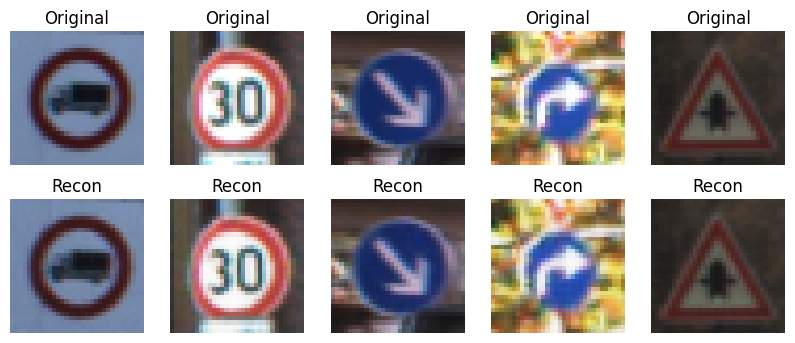

In [ ]:
import matplotlib.pyplot as plt

def visualize_reconstruction(model, loader, device):
    model.eval()
    x, _, _ = next(iter(loader))
    x = x.to(device)
    with torch.no_grad():
        recon = model(x)
    
    # Un-normalize for visualization: [-1, 1] -> [0, 1]
    x = x * 0.5 + 0.5
    recon = recon * 0.5 + 0.5
    
    # Plot first 5 images
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i in range(5):
        axes[0, i].imshow(x[i].permute(1, 2, 0).cpu().numpy())
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(recon[i].permute(1, 2, 0).cpu().numpy())
        axes[1, i].set_title("Recon")
        axes[1, i].axis('off')
    # plt.savefig("ae_debug.png")
    print("Saved visualization to ae_debug.png")

# Call this after defense.train_autoencoder(...)
visualize_reconstruction(ae_model, DataLoader(test_clean, batch_size=16), DEVICE)

Loading Data...
>>> Training AutoEncoder on cuda...
This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 39209
Total test samples: 12630
Batch size: 256
iteration every epoch: 153
Initial learning rate: 0.001

[2026-02-04_13:42:48] Epoch:1/20, iteration:100/153, lr: 0.001, loss: 0.02152034267783165, time: 1.68638277053833

[2026-02-04_13:42:50] Epoch:2/20, iteration:46/153, lr: 0.001, loss: 0.01121335756033659, time: 1.6756272315979004

[2026-02-04_13:42:51] Epoch:2/20, iteration:146/153, lr: 0.001, loss: 0.00936603732407093, time: 1.237269639968872

[2026-02-04_13:42:53] Epoch:3/20, iteration:92/153, lr: 0.001, loss: 0.008043540641665459, time: 1.7616682052612305

[2026-02-04_13:42:55] Epoch:4/20, iteration:38/153, lr: 0.001, loss: 0.0073421127162873745, time: 1.7602074146270752

[2026-02-04_13:42:56] Epoch:4/20, iteration:138/153, lr: 0.001, loss: 0.0052813454531133175, time: 1.2948591709136963

[2026-02-04_13:42:58] Epoch:5/20, iteration:84/153, lr: 0.00

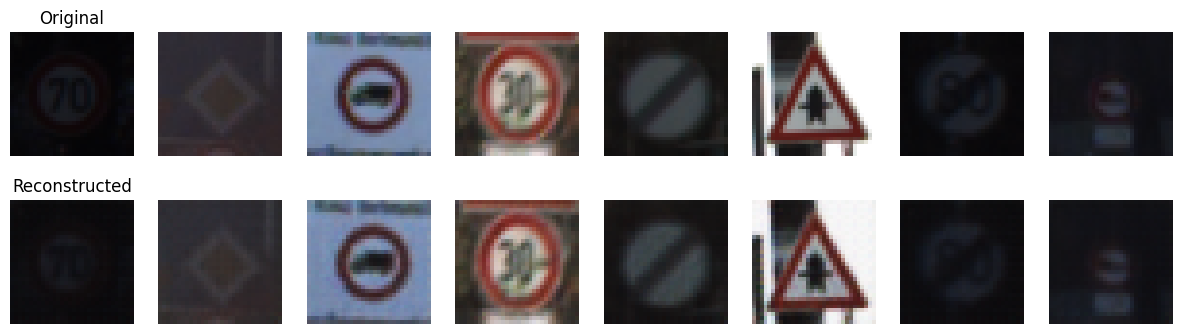

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import sys
import os

# Import your wrapper
from GTSRB import GTSRB_Wrapper

# Import the library directly (now that it is patched)
sys.path.append(os.path.join(os.getcwd(), '..'))
from BackdoorBox.core.defenses.AutoEncoderDefense import AutoEncoderDefense

# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 256
LR = 0.001
EPOCHS = 20
POISON_RATE = 0.05 

# ==========================================
# 1. MODEL DEFINITION (Must define this yourself)
# ==========================================
class SimpleAutoEncoder(nn.Module):
    def __init__(self):
        super(SimpleAutoEncoder, self).__init__()
        # Encoder: 32x32 -> 16x16 -> 8x8
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        # Decoder: 8x8 -> 16x16 -> 32x32
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh() # Output [-1, 1]
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ==========================================
# 2. LOAD DATA
# ==========================================
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

print("Loading Data...")
train_set = GTSRB_Wrapper(mode='train', poison_type='black_1', poison_rate=POISON_RATE, transform=transform)
test_clean = GTSRB_Wrapper(mode='test', poison_type='black_1', poison_rate=0.0, transform=transform)

# ==========================================
# 3. RUN TRAINING (Using Library)
# ==========================================
ae_model = SimpleAutoEncoder().to(DEVICE)

# Initialize Library Defense
defense = AutoEncoderDefense(autoencoder=ae_model, seed=0)

schedule = {
    'device': 'GPU' if torch.cuda.is_available() else 'CPU',
    'GPU_num': 1,
    'CUDA_VISIBLE_DEVICES': '0',
    'batch_size': BATCH_SIZE,
    'num_workers': 8,
    'lr': LR,
    'epochs': EPOCHS,
    'betas': (0.9, 0.999),
    'eps': 1e-8,
    'weight_decay': 0,
    'amsgrad': False,
    'log_iteration_interval': 100,
    'test_epoch_interval': 5,
    'save_epoch_interval': 10,
    'save_dir': 'ae_logs',
    'experiment_name': 'gtsrb_ae',
    'schedule': [10, 15], 
    'gamma': 0.1
}

print(f">>> Training AutoEncoder on {DEVICE}...")
defense.train_autoencoder(train_set, test_clean, schedule)


# ==========================================
# 4. VISUALIZATION (Verify Output)
# ==========================================
def visualize_results(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=8)
    images = next(iter(loader))[0].to(DEVICE) # Handle tuple safely if needed, or index 0
    
    with torch.no_grad():
        recon = model(images)
    
    # Un-normalize for display: [-1, 1] -> [0, 1]
    images = images.cpu() * 0.5 + 0.5
    recon = recon.cpu() * 0.5 + 0.5
    
    plt.figure(figsize=(15, 4))
    for i in range(8):
        # Original
        ax = plt.subplot(2, 8, i + 1)
        plt.imshow(images[i].permute(1, 2, 0).numpy())
        plt.axis("off")
        if i == 0: ax.set_title("Original")
        
        # Reconstructed
        ax = plt.subplot(2, 8, i + 1 + 8)
        plt.imshow(recon[i].permute(1, 2, 0).numpy())
        plt.axis("off")
        if i == 0: ax.set_title("Reconstructed")
    plt.show()

print("\n>>> Checking Reconstruction Quality...")
visualize_results(ae_model, test_clean)

Checking if AutoEncoder removes the trigger...
Top: Poisoned Input (Look for the Trigger!)
Bottom: Purified Output (Trigger should be gone/blurry)


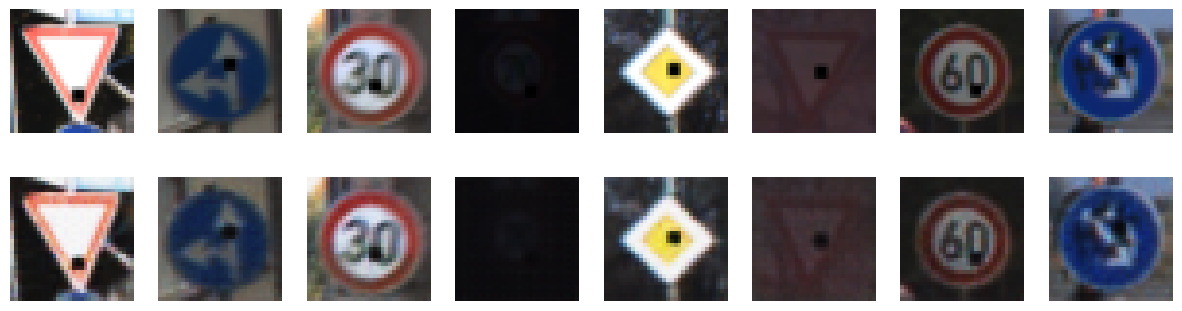

In [15]:
def visualize_poison_removal(model, dataset):
    model.eval()
    # 1. Filter loader to only get POISONED images (flag=1)
    # We iterate until we find a batch with poisons
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    found = False
    while not found:
        # Unpack tuple safely (img, label, is_poison)
        batch = next(iter(loader))
        images, labels, is_poison = batch
        
        # Get indices where is_poison == 1
        poison_idx = (is_poison == 1).nonzero(as_tuple=True)[0]
        
        if len(poison_idx) >= 8: # We want at least 8 examples
            images = images[poison_idx[:8]].to(DEVICE)
            found = True

    # 2. Reconstruct
    with torch.no_grad():
        recon = model(images)
    
    # 3. Plot
    images = images.cpu() * 0.5 + 0.5
    recon = recon.cpu() * 0.5 + 0.5
    
    plt.figure(figsize=(15, 4))
    print("Top: Poisoned Input (Look for the Trigger!)")
    print("Bottom: Purified Output (Trigger should be gone/blurry)")
    
    for i in range(8):
        # Original
        ax = plt.subplot(2, 8, i + 1)
        plt.imshow(images[i].permute(1, 2, 0).numpy())
        plt.axis("off")
        
        # Reconstructed
        ax = plt.subplot(2, 8, i + 1 + 8)
        plt.imshow(recon[i].permute(1, 2, 0).numpy())
        plt.axis("off")
    plt.show()

# Run on your TRAIN set (which contains the poisons)
print("Checking if AutoEncoder removes the trigger...")
visualize_poison_removal(ae_model, train_set)

Loading Data...
>>> Training Denoising AE (Noise=0.2)...
    Epoch 5: Loss = 0.0128
    Epoch 10: Loss = 0.0098
    Epoch 15: Loss = 0.0084
    Epoch 20: Loss = 0.0080
    Epoch 25: Loss = 0.0076

>>> VISUALIZING RESULTS...


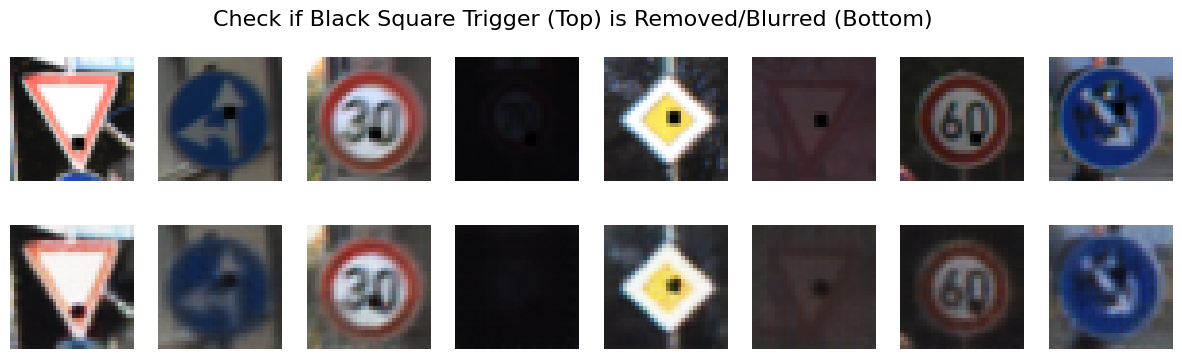

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import sys
import os
import numpy as np

# --- 1. SETUP & IMPORTS ---
# Add path to library
sys.path.append(os.path.join(os.getcwd(), '..'))
from BackdoorBox.core.defenses.AutoEncoderDefense import AutoEncoderDefense
from GTSRB import GTSRB_Wrapper

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 256
LR = 0.001
EPOCHS = 25  # Slightly more epochs for Denoising AE
POISON_RATE = 0.05 

# --- 2. REDUCED CAPACITY MODEL ---
# We halve the channels (16->32 instead of 32->64) to force compression
class SmallAutoEncoder(nn.Module):
    def __init__(self):
        super(SmallAutoEncoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh() 
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# --- 3. DENOISING DEFENSE CLASS ---
class DenoisingAutoEncoderDefense(AutoEncoderDefense):
    def train_autoencoder(self, train_dataset, test_dataset, schedule):
        train_loader = DataLoader(train_dataset, batch_size=schedule['batch_size'], shuffle=True, num_workers=8)
        
        self.autoencoder = self.autoencoder.to(DEVICE)
        self.autoencoder.train()
        
        optimizer = optim.Adam(self.autoencoder.parameters(), lr=schedule['lr'])
        criterion = nn.MSELoss() 
        
        print(f">>> Training Denoising AE (Noise={schedule.get('noise_factor', 0.2)})...")
        
        for epoch in range(schedule['epochs']):
            total_loss = 0
            for batch in train_loader:
                img = batch[0].to(DEVICE) # Safe unpack
                
                # ADD NOISE
                noise_factor = schedule.get('noise_factor', 0.2)
                noise = torch.randn_like(img) * noise_factor
                noisy_img = img + noise
                
                # Predict from NOISY, compare to CLEAN
                recon = self.autoencoder(noisy_img)
                loss = criterion(recon, img)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            
            if (epoch + 1) % 5 == 0:
                print(f"    Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

    def preprocess(self, data):
        with torch.no_grad():
            self.autoencoder.eval()
            data = data.to(DEVICE)
            if data.ndim == 3:
                return self.autoencoder(data.unsqueeze(0))[0]
            return self.autoencoder(data)

# --- 4. LOAD DATA ---
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

print("Loading Data...")
train_set = GTSRB_Wrapper(mode='train', poison_type='black_1', poison_rate=POISON_RATE, transform=transform)
test_clean = GTSRB_Wrapper(mode='test', poison_type='black_1', poison_rate=0.0, transform=transform)

# --- 5. EXECUTE TRAINING ---
ae_model = SmallAutoEncoder()
defense = DenoisingAutoEncoderDefense(autoencoder=ae_model)

schedule = {
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'epochs': EPOCHS,
    'noise_factor': 0.2 # Standard noise amount
}

defense.train_autoencoder(train_set, test_clean, schedule)

# --- 6. VERIFY POISON REMOVAL ---
def check_poison_removal(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    # Find a batch with actual poisons
    found = False
    while not found:
        batch = next(iter(loader))
        images, labels, is_poison = batch
        poison_idx = (is_poison == 1).nonzero(as_tuple=True)[0]
        if len(poison_idx) >= 8:
            images = images[poison_idx[:8]].to(DEVICE)
            found = True

    with torch.no_grad():
        recon = model(images)
    
    # Plot
    images = images.cpu() * 0.5 + 0.5
    recon = recon.cpu() * 0.5 + 0.5
    
    plt.figure(figsize=(15, 4))
    plt.suptitle("Check if Black Square Trigger (Top) is Removed/Blurred (Bottom)", fontsize=16)
    for i in range(8):
        # Original
        ax = plt.subplot(2, 8, i + 1)
        plt.imshow(images[i].permute(1, 2, 0).numpy())
        plt.axis("off")
        
        # Reconstructed
        ax = plt.subplot(2, 8, i + 1 + 8)
        plt.imshow(recon[i].permute(1, 2, 0).numpy())
        plt.axis("off")
    plt.show()

print("\n>>> VISUALIZING RESULTS...")
check_poison_removal(ae_model, train_set)

In [20]:
# ==========================================
# 7. FINAL EVALUATION: ACCURACY vs ASR
# ==========================================

# 1. Load the BadNet Classifier (The victim model)
# We assume you have the architecture from before. 
# If you trained it in a previous cell, 'badnet' might already be in memory.
# If not, uncomment the lines below to load it from file.
# badnet = get_badnet() # Define this function as in previous steps if needed
# badnet.load_state_dict(torch.load("badnet_gtsrb.pth")) 
badnet.to(DEVICE)
badnet.eval()

# 2. Define the Evaluation Pipeline
def eval_defense_pipeline(classifier, defense_model, loader, device, metric_name):
    """
    1. Purify input x using AutoEncoder.
    2. Predict using Classifier.
    3. Compare against y.
    """
    classifier.eval()
    defense_model.eval()
    
    correct = 0
    total = 0
    
    print(f"Running {metric_name}...", end="")
    
    with torch.no_grad():
        for batch in loader:
            # Unpack safely (handle 2 or 3 items)
            x = batch[0].to(device)
            y = batch[1].to(device)
            
            # --- STEP 1: PURIFY ---
            # Pass through Denoising AutoEncoder
            x_purified = defense_model(x)
            
            # --- STEP 2: CLASSIFY ---
            # Pass purified image to BadNet
            outputs = classifier(x_purified)
            _, predicted = torch.max(outputs, 1)
            
            total += y.size(0)
            correct += (predicted == y).sum().item()
            
    acc = 100 * correct / total
    print(f" Done. Result: {acc:.2f}%")
    return acc

# 3. Prepare Loaders
# Clean Test Set (Labels are correct)
loader_clean = DataLoader(test_clean, batch_size=64, shuffle=False)

# Poison Test Set (All images have triggers, Labels = Target(5))
# We check how many are successfully classified as Target(5)
loader_poison = DataLoader(test_poison, batch_size=64, shuffle=False)

print("\n" + "="*40)
print("FINAL DEFENSE RESULTS")
print("="*40)

# --- BASELINE (No Defense) ---
# Quick check to see original BadNet performance for comparison
# print("\n[Baseline - No Defense]")
base_acc = eval_defense_pipeline(model, nn.Identity(), loader_clean, DEVICE, "Clean Accuracy")
base_asr = eval_defense_pipeline(model, nn.Identity(), loader_poison, DEVICE, "Attack Success Rate")

# --- DEFENDED (With Denoising AE) ---
print("\n[Defended - Denoising AE]")
# Check Clean Accuracy (Did we break the model?)
# Expect a small drop (e.g. 94% -> 85%) due to blurring
def_acc = eval_defense_pipeline(badnet, ae_model, loader_clean, DEVICE, "Clean Accuracy")

# Check ASR (Did we stop the attack?)
# Expect a MASSIVE drop (e.g. 97% -> 5%) if the trigger is removed
def_asr = eval_defense_pipeline(badnet, ae_model, loader_poison, DEVICE, "Attack Success Rate")

print("\n" + "-"*40)
print(f"{'Metric':<20} | {'Baseline':<10} | {'Defended':<10}")
print("-" * 40)
print(f"{'Clean Accuracy':<20} | {base_acc:.2f}% | {def_acc:.2f}%")
print(f"{'ASR (Poison)':<20} | {base_asr:.2f}% | {def_asr:.2f}%")
print("-" * 40)


FINAL DEFENSE RESULTS
Running Clean Accuracy... Done. Result: 94.49%
Running Attack Success Rate... Done. Result: 97.24%

[Defended - Denoising AE]
Running Clean Accuracy... Done. Result: 3.09%
Running Attack Success Rate... Done. Result: 0.00%

----------------------------------------
Metric               | Baseline   | Defended  
----------------------------------------
Clean Accuracy       | 94.49% | 3.09%
ASR (Poison)         | 97.24% | 0.00%
----------------------------------------


Batch size=128 | poisoned in batch=6 | poison_rate approx=0.047


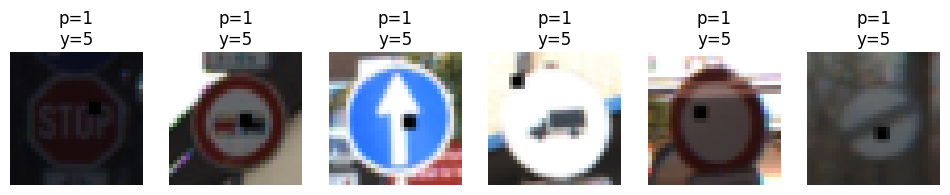

In [21]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def unnorm(x):  # [-1,1] -> [0,1]
    return (x * 0.5 + 0.5).clamp(0, 1)

loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)

x, y, is_poison = next(iter(loader))
p = (is_poison == 1).nonzero(as_tuple=True)[0]
print(f"Batch size={len(x)} | poisoned in batch={len(p)} | poison_rate approx={len(p)/len(x):.3f}")

# Show up to 8 poisoned images if present (else show first 8)
idxs = p[:8] if len(p) > 0 else torch.arange(8)
imgs = unnorm(x[idxs])

plt.figure(figsize=(12,3))
for i in range(len(idxs)):
    ax = plt.subplot(1, len(idxs), i+1)
    plt.imshow(imgs[i].permute(1,2,0))
    plt.axis("off")
    plt.title(f"p={int(is_poison[idxs[i]])}\ny={int(y[idxs[i]])}")
plt.show()


In [22]:
import torch
import torch.nn as nn
from torchvision import models

def get_badnet():
    m = models.resnet18(num_classes=43)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m

m_mod = get_badnet()
m_van = models.resnet18(num_classes=43)

print("Modified conv1:", m_mod.conv1)
print("Vanilla  conv1:", m_van.conv1)
print("Modified maxpool:", m_mod.maxpool)
print("Vanilla  maxpool:", m_van.maxpool)

# Quick forward shape check
x = torch.randn(4,3,32,32)
with torch.no_grad():
    out = m_mod(x)
print("Forward OK, out shape:", out.shape)


Modified conv1: Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Vanilla  conv1: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Modified maxpool: Identity()
Vanilla  maxpool: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
Forward OK, out shape: torch.Size([4, 43])


In [23]:
import torch
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def eval_acc(model, loader):
    model.eval()
    c, t = 0, 0
    with torch.no_grad():
        for x, y, *_ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            c += (pred == y).sum().item()
            t += y.size(0)
    return 100 * c / t

# Build correct architecture
badnet = get_badnet().to(DEVICE)

# LOAD YOUR CHECKPOINT (edit filename!)
ckpt_path = "badnet_gtsrb.pth"  # <-- change if needed
sd = torch.load(ckpt_path, map_location=DEVICE)
badnet.load_state_dict(sd)
badnet.eval()

# DataLoaders
clean_loader  = DataLoader(test_clean,  batch_size=256, shuffle=False, num_workers=4)
poison_loader = DataLoader(test_poison, batch_size=256, shuffle=False, num_workers=4)

clean_acc = eval_acc(badnet, clean_loader)
poison_acc = eval_acc(badnet, poison_loader)  # equals ASR with your wrapper labels

print(f"[Baseline] Clean Acc = {clean_acc:.2f}% | Poison Acc (=ASR) = {poison_acc:.2f}%")

# Extra: random-weights check should be ~2-3%
rnd = get_badnet().to(DEVICE)
rnd_clean = eval_acc(rnd, clean_loader)
print(f"[Random net sanity] Clean Acc = {rnd_clean:.2f}% (should be ~2-3%)")


FileNotFoundError: [Errno 2] No such file or directory: 'badnet_gtsrb.pth'

In [2]:
# === ONE CELL: Train BadNet + Train BackdoorBox AutoEncoderDefense (clean-only) + Evaluate ===
import os, random, numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models

from GTSRB import GTSRB_Wrapper

# ---- BackdoorBox defense (your installed one) ----
# adjust path if needed
import sys
sys.path.append(os.path.join(os.getcwd(), ".."))
from BackdoorBox.core.defenses.AutoEncoderDefense import AutoEncoderDefense

# ---- Repro ----
SEED = 0
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ---- Config ----
POISON_TYPE   = "black_1"
TARGET_LABEL  = 5
POISON_RATE   = 0.05

EPOCHS_BADNET = 15
BATCH_BADNET  = 256
LR_BADNET     = 0.01

EPOCHS_AE     = 20
BATCH_AE      = 256
LR_AE         = 1e-3

# ---- Transform (keep consistent everywhere!) ----
# You are using Normalize -> range becomes ~[-1, 1].
# BackdoorBox code doesn't *actually* enforce [0,1]; it just passes tensors through.
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

# ---- Datasets (IMPORTANT: AE is trained on CLEAN ONLY) ----
train_poison = GTSRB_Wrapper(mode="train", poison_type=POISON_TYPE, poison_rate=POISON_RATE,
                            transform=transform, target_label=TARGET_LABEL)
train_clean  = GTSRB_Wrapper(mode="train", poison_type=POISON_TYPE, poison_rate=0.0,
                            transform=transform, target_label=TARGET_LABEL)

test_clean   = GTSRB_Wrapper(mode="test",  poison_type=POISON_TYPE, poison_rate=0.0,
                            transform=transform, target_label=TARGET_LABEL)
test_poison  = GTSRB_Wrapper(mode="test",  poison_type=POISON_TYPE, poison_rate=1.0,
                            transform=transform, target_label=TARGET_LABEL)

# ---- Loaders ----
train_poison_loader = DataLoader(train_poison, batch_size=BATCH_BADNET, shuffle=True,  num_workers=8, pin_memory=True)
test_clean_loader   = DataLoader(test_clean,   batch_size=256,         shuffle=False, num_workers=8, pin_memory=True)
test_poison_loader  = DataLoader(test_poison,  batch_size=256,         shuffle=False, num_workers=8, pin_memory=True)

# ---- BadNet model: MUST match training/eval architecture ----
def get_badnet():
    m = models.resnet18(num_classes=43)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m

@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    c, t = 0, 0
    for x, y, *_ in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        pred = model(x).argmax(1)
        c += (pred == y).sum().item()
        t += y.size(0)
    return 100 * c / t

# ---- 1) Train BadNet on POISONED train set ----
badnet = get_badnet().to(DEVICE)
crit = nn.CrossEntropyLoss()
opt = optim.SGD(badnet.parameters(), lr=LR_BADNET, momentum=0.9, weight_decay=5e-4)
sch = optim.lr_scheduler.MultiStepLR(opt, milestones=[10], gamma=0.1)

print("\n=== Training BadNet (poisoned train) ===")
for epoch in range(1, EPOCHS_BADNET + 1):
    badnet.train()
    loss_sum = 0.0
    for x, y, *_ in train_poison_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        out = badnet(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        loss_sum += loss.item()
    sch.step()

    if epoch in [1,2,3,5,10,15]:
        clean_acc = eval_acc(badnet, test_clean_loader)
        asr = eval_acc(badnet, test_poison_loader)  # poison labels are target => accuracy == ASR
        print(f"Epoch {epoch:>2}/{EPOCHS_BADNET} | loss={loss_sum/len(train_poison_loader):.4f} | clean={clean_acc:.2f}% | ASR={asr:.2f}%")

baseline_clean = eval_acc(badnet, test_clean_loader)
baseline_asr   = eval_acc(badnet, test_poison_loader)
print(f"\n[Baseline] Clean={baseline_clean:.2f}% | ASR={baseline_asr:.2f}%")

# ---- 2) Define a SMALL AE (bottleneck helps it *not* perfectly copy trigger) ----
class SmallAE(nn.Module):
    def __init__(self):
        super().__init__()
        # 32 -> 16 -> 8 bottleneck, fewer channels
        self.enc = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 3,  3, stride=2, padding=1, output_padding=1),
            nn.Tanh(),  # matches your normalized space roughly [-1,1]
        )
    def forward(self, x):
        return self.dec(self.enc(x))

ae_model = SmallAE()

# ---- 3) Train AE using BackdoorBox AutoEncoderDefense on CLEAN-ONLY train set ----
defense = AutoEncoderDefense(autoencoder=ae_model, seed=SEED)

schedule = {
    "device": "GPU" if torch.cuda.is_available() else "CPU",
    "GPU_num": 1,
    "CUDA_VISIBLE_DEVICES": "0",
    "batch_size": BATCH_AE,
    "num_workers": 8,
    "lr": LR_AE,
    "epochs": EPOCHS_AE,
    "betas": (0.9, 0.999),
    "eps": 1e-8,
    "weight_decay": 0,
    "amsgrad": False,
    "log_iteration_interval": 200,
    "test_epoch_interval": 5,
    "save_epoch_interval": 999999,  # don't spam checkpoints
    "save_dir": "ae_logs",
    "experiment_name": "gtsrb_ae_clean_only",
    "schedule": [10, 15],
    "gamma": 0.1,
}

print("\n=== Training AE (BackdoorBox) on CLEAN-ONLY train set ===")
defense.train_autoencoder(train_clean, test_clean, schedule)

# ---- 4) Evaluate defended pipeline (using defense.preprocess) ----
@torch.no_grad()
def eval_with_defense(clf, defense_obj, loader):
    clf.eval()
    c, t = 0, 0
    for x, y, *_ in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        x2 = defense_obj.preprocess(x)            # BackdoorBox purifier
        x2 = torch.clamp(x2, -1, 1)              # keep in expected normalized range
        pred = clf(x2).argmax(1)
        c += (pred == y).sum().item()
        t += y.size(0)
    return 100 * c / t

def_clean = eval_with_defense(badnet, defense, test_clean_loader)
def_asr   = eval_with_defense(badnet, defense, test_poison_loader)

print("\n=== FINAL RESULTS ===")
print(f"Baseline: Clean={baseline_clean:.2f}% | ASR={baseline_asr:.2f}%")
print(f"Defended: Clean={def_clean:.2f}% | ASR={def_asr:.2f}%")


DEVICE: cuda

=== Training BadNet (poisoned train) ===
Epoch  1/15 | loss=2.1092 | clean=67.63% | ASR=22.80%
Epoch  2/15 | loss=0.4524 | clean=79.14% | ASR=82.97%
Epoch  3/15 | loss=0.1041 | clean=71.40% | ASR=99.64%
Epoch  5/15 | loss=0.0169 | clean=93.46% | ASR=97.62%
Epoch 10/15 | loss=0.0030 | clean=94.63% | ASR=96.96%
Epoch 15/15 | loss=0.0025 | clean=94.62% | ASR=97.21%

[Baseline] Clean=94.62% | ASR=97.21%

=== Training AE (BackdoorBox) on CLEAN-ONLY train set ===
This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 39209
Total test samples: 12630
Batch size: 256
iteration every epoch: 153
Initial learning rate: 0.001



/home/tobiasponeschtu/Documents/184.702_MachineLearning/Ex3/src/../BackdoorBox/core/defenses/AutoEncoderDefense.py:156: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  msg = time.strftime("[%Y-%m-%d_%H:%M:%S] ", time.localtime()) + f"Epoch:{i+1}/{schedule['epochs']}, iteration:{batch_id + 1}/{len(train_dataset)//schedule['batch_size']}, lr: {schedule['lr']}, loss: {float(loss)}, time: {time.time()-last_time}\n"


[2026-02-04_14:17:30] Epoch:2/20, iteration:46/153, lr: 0.001, loss: 0.017264312133193016, time: 2.8647775650024414

[2026-02-04_14:17:33] Epoch:3/20, iteration:92/153, lr: 0.001, loss: 0.010743103921413422, time: 2.6602509021759033

[2026-02-04_14:17:36] Epoch:4/20, iteration:138/153, lr: 0.001, loss: 0.007026625331491232, time: 2.4711077213287354

==========Test result on test dataset==========
[2026-02-04_14:17:39] loss: 0.005845993757247925, time: 3.2349157333374023

[2026-02-04_14:17:39] Epoch:6/20, iteration:30/153, lr: 0.001, loss: 0.005569023080170155, time: 3.919039487838745

[2026-02-04_14:17:42] Epoch:7/20, iteration:76/153, lr: 0.001, loss: 0.004836957901716232, time: 2.5346031188964844

[2026-02-04_14:17:45] Epoch:8/20, iteration:122/153, lr: 0.001, loss: 0.0036981855519115925, time: 2.6489522457122803

[2026-02-04_14:17:48] Epoch:10/20, iteration:14/153, lr: 0.001, loss: 0.003747065318748355, time: 2.893104314804077

==========Test result on test dataset==========
[2026-0

In [3]:
import os, random, numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models

from GTSRB import GTSRB_Wrapper

# ---- BackdoorBox defense (only import here so it's available later) ----
import sys
sys.path.append(os.path.join(os.getcwd(), ".."))
from BackdoorBox.core.defenses.AutoEncoderDefense import AutoEncoderDefense

# ---- Repro ----
SEED = 0
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ---- Config ----
POISON_TYPE   = "black_1"
TARGET_LABEL  = 5
POISON_RATE   = 0.05

EPOCHS_BADNET = 15
BATCH_BADNET  = 256
LR_BADNET     = 0.01

# ---- Transform (keep consistent everywhere!) ----
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

# ---- Datasets ----
train_poison = GTSRB_Wrapper(mode="train", poison_type=POISON_TYPE, poison_rate=POISON_RATE,
                            transform=transform, target_label=TARGET_LABEL)

# IMPORTANT: AE will be trained on CLEAN ONLY
train_clean  = GTSRB_Wrapper(mode="train", poison_type=POISON_TYPE, poison_rate=0.0,
                            transform=transform, target_label=TARGET_LABEL)

test_clean   = GTSRB_Wrapper(mode="test",  poison_type=POISON_TYPE, poison_rate=0.0,
                            transform=transform, target_label=TARGET_LABEL)

test_poison  = GTSRB_Wrapper(mode="test",  poison_type=POISON_TYPE, poison_rate=1.0,
                            transform=transform, target_label=TARGET_LABEL)

# ---- Loaders ----
train_poison_loader = DataLoader(train_poison, batch_size=BATCH_BADNET, shuffle=True,  num_workers=8, pin_memory=True)
test_clean_loader   = DataLoader(test_clean,   batch_size=256,         shuffle=False, num_workers=8, pin_memory=True)
test_poison_loader  = DataLoader(test_poison,  batch_size=256,         shuffle=False, num_workers=8, pin_memory=True)

# ---- BadNet model: MUST match training/eval architecture ----
def get_badnet():
    m = models.resnet18(num_classes=43)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m

@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    c, t = 0, 0
    for x, y, *_ in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        pred = model(x).argmax(1)
        c += (pred == y).sum().item()
        t += y.size(0)
    return 100 * c / t

@torch.no_grad()
def eval_with_defense(clf, defense_obj, loader):
    clf.eval()
    c, t = 0, 0
    for x, y, *_ in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        x2 = defense_obj.preprocess(x)
        x2 = torch.clamp(x2, -1, 1)
        pred = clf(x2).argmax(1)
        c += (pred == y).sum().item()
        t += y.size(0)
    return 100 * c / t

# ---- 1) Train BadNet on POISONED train set (run once) ----
badnet = get_badnet().to(DEVICE)
crit = nn.CrossEntropyLoss()
opt = optim.SGD(badnet.parameters(), lr=LR_BADNET, momentum=0.9, weight_decay=5e-4)
sch = optim.lr_scheduler.MultiStepLR(opt, milestones=[10], gamma=0.1)

print("\n=== Training BadNet (poisoned train) ===")
for epoch in range(1, EPOCHS_BADNET + 1):
    badnet.train()
    loss_sum = 0.0
    for x, y, *_ in train_poison_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        out = badnet(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        loss_sum += loss.item()
    sch.step()

    if epoch in [1,2,3,5,10,15]:
        clean_acc = eval_acc(badnet, test_clean_loader)
        asr = eval_acc(badnet, test_poison_loader)  # poison labels are target => accuracy == ASR
        print(f"Epoch {epoch:>2}/{EPOCHS_BADNET} | loss={loss_sum/len(train_poison_loader):.4f} | clean={clean_acc:.2f}% | ASR={asr:.2f}%")

baseline_clean = eval_acc(badnet, test_clean_loader)
baseline_asr   = eval_acc(badnet, test_poison_loader)
print(f"\n[Baseline] Clean={baseline_clean:.2f}% | ASR={baseline_asr:.2f}%")


DEVICE: cuda

=== Training BadNet (poisoned train) ===
Epoch  1/15 | loss=2.1360 | clean=51.08% | ASR=31.73%
Epoch  2/15 | loss=0.4502 | clean=86.25% | ASR=89.39%
Epoch  3/15 | loss=0.0989 | clean=87.50% | ASR=98.81%
Epoch  5/15 | loss=0.0210 | clean=93.42% | ASR=97.77%
Epoch 10/15 | loss=0.0029 | clean=94.47% | ASR=97.47%
Epoch 15/15 | loss=0.0025 | clean=94.46% | ASR=97.65%

[Baseline] Clean=94.46% | ASR=97.65%


In [6]:
# ---- Defense config (same) ----
EPOCHS_AE = 20
BATCH_AE  = 256
LR_AE     = 1e-3

# ---- TightAE v2: still 32->16->8->4 bottleneck, but wider channels ----
class TightAEv2(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 32 -> 16 -> 8 -> 4
        self.enc = nn.Sequential(
            nn.Conv2d(3, 12, 3, stride=2, padding=1),   # 16x16
            nn.ReLU(inplace=True),
            nn.Conv2d(12, 24, 3, stride=2, padding=1),  # 8x8
            nn.ReLU(inplace=True),
            nn.Conv2d(24, 24, 3, stride=2, padding=1),  # 4x4 bottleneck
            nn.ReLU(inplace=True),
        )
        # Decoder: 4 -> 8 -> 16 -> 32
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(24, 24, 3, stride=2, padding=1, output_padding=1), # 8x8
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(24, 12, 3, stride=2, padding=1, output_padding=1), # 16x16
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(12, 3, 3, stride=2, padding=1, output_padding=1),  # 32x32
            nn.Tanh(),
        )

    def forward(self, x):
        return self.dec(self.enc(x))

ae_model = TightAEv2()

# ---- Train AE using BackdoorBox AutoEncoderDefense on CLEAN-ONLY train set ----
defense = AutoEncoderDefense(autoencoder=ae_model, seed=SEED)

schedule = {
    "device": "GPU" if torch.cuda.is_available() else "CPU",
    "GPU_num": 1,
    "CUDA_VISIBLE_DEVICES": "0",
    "batch_size": BATCH_AE,
    "num_workers": 8,
    "lr": LR_AE,
    "epochs": EPOCHS_AE,
    "betas": (0.9, 0.999),
    "eps": 1e-8,
    "weight_decay": 0,
    "amsgrad": False,
    "log_iteration_interval": 200,
    "test_epoch_interval": 5,
    "save_epoch_interval": 999999,
    "save_dir": "ae_logs",
    "experiment_name": "gtsrb_ae_tight_v2_clean_only",
    "schedule": [10, 15],
    "gamma": 0.1,
}

print("\n=== Training TightAEv2 (BackdoorBox) on CLEAN-ONLY train set ===")
defense.train_autoencoder(train_clean, test_clean, schedule)

# ---- Evaluate defended pipeline ----
def_clean = eval_with_defense(badnet, defense, test_clean_loader)
def_asr   = eval_with_defense(badnet, defense, test_poison_loader)

print("\n=== FINAL RESULTS (TightAEv2) ===")
print(f"Baseline: Clean={baseline_clean:.2f}% | ASR={baseline_asr:.2f}%")
print(f"Defended: Clean={def_clean:.2f}% | ASR={def_asr:.2f}%")



=== Training TightAEv2 (BackdoorBox) on CLEAN-ONLY train set ===
This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 39209
Total test samples: 12630
Batch size: 256
iteration every epoch: 153
Initial learning rate: 0.001

[2026-02-04_14:30:50] Epoch:2/20, iteration:46/153, lr: 0.001, loss: 0.043145593255758286, time: 3.086170196533203

[2026-02-04_14:30:53] Epoch:3/20, iteration:92/153, lr: 0.001, loss: 0.035339128226041794, time: 2.665146827697754

[2026-02-04_14:30:55] Epoch:4/20, iteration:138/153, lr: 0.001, loss: 0.02271403931081295, time: 2.608858823776245

==========Test result on test dataset==========
[2026-02-04_14:30:59] loss: 0.020653316751122475, time: 3.4252817630767822

[2026-02-04_14:30:59] Epoch:6/20, iteration:30/153, lr: 0.001, loss: 0.019877146929502487, time: 4.127423048019409

[2026-02-04_14:31:02] Epoch:7/20, iteration:76/153, lr: 0.001, loss: 0.01749398186802864, time: 2.700087070465088

[2026-02-04_14:31:05] Epoch:8/20, iteration:

In [ ]:
# ---- Defense config (same) ----
EPOCHS_AE = 20
BATCH_AE  = 256
LR_AE     = 1e-3

class TightAEv3_Drop(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 12, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.10),

            nn.Conv2d(12, 24, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.10),

            nn.Conv2d(24, 24, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.10),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(24, 24, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(24, 12, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(12, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh(),
        )
    def forward(self, x):
        return self.dec(self.enc(x))

ae_model = TightAEv3_Drop()

# ---- Train AE using BackdoorBox AutoEncoderDefense on CLEAN-ONLY train set ----
defense = AutoEncoderDefense(autoencoder=ae_model, seed=SEED)

schedule = {
    "device": "GPU" if torch.cuda.is_available() else "CPU",
    "GPU_num": 1,
    "CUDA_VISIBLE_DEVICES": "0",
    "batch_size": BATCH_AE,
    "num_workers": 8,
    "lr": LR_AE,
    "epochs": EPOCHS_AE,
    "betas": (0.9, 0.999),
    "eps": 1e-8,
    "weight_decay": 0,
    "amsgrad": False,
    "log_iteration_interval": 200,
    "test_epoch_interval": 5,
    "save_epoch_interval": 999999,
    "save_dir": "ae_logs",
    "experiment_name": "gtsrb_ae_tight_v2_clean_only",
    "schedule": [10, 15],
    "gamma": 0.1,
}

print("\n=== Training TightAEv2 (BackdoorBox) on CLEAN-ONLY train set ===")
defense.train_autoencoder(train_clean, test_clean, schedule)

# ---- Evaluate defended pipeline ----
def_clean = eval_with_defense(badnet, defense, test_clean_loader)
def_asr   = eval_with_defense(badnet, defense, test_poison_loader)

print("\n=== FINAL RESULTS (TightAEv4_Bneck) ===")
print(f"Baseline: Clean={baseline_clean:.2f}% | ASR={baseline_asr:.2f}%")
print(f"Defended: Clean={def_clean:.2f}% | ASR={def_asr:.2f}%")



=== Training TightAEv2 (BackdoorBox) on CLEAN-ONLY train set ===
This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 39209
Total test samples: 12630
Batch size: 256
iteration every epoch: 153
Initial learning rate: 0.001

[2026-02-04_14:33:07] Epoch:2/20, iteration:46/153, lr: 0.001, loss: 0.05377892777323723, time: 3.117396354675293

[2026-02-04_14:33:10] Epoch:3/20, iteration:92/153, lr: 0.001, loss: 0.05167701095342636, time: 2.722787380218506

[2026-02-04_14:33:12] Epoch:4/20, iteration:138/153, lr: 0.001, loss: 0.03882496431469917, time: 2.5280678272247314

==========Test result on test dataset==========
[2026-02-04_14:33:16] loss: 0.03322609141469002, time: 3.4258124828338623

[2026-02-04_14:33:17] Epoch:6/20, iteration:30/153, lr: 0.001, loss: 0.0380932055413723, time: 4.110935211181641

[2026-02-04_14:33:19] Epoch:7/20, iteration:76/153, lr: 0.001, loss: 0.036224812269210815, time: 2.786755084991455

[2026-02-04_14:33:22] Epoch:8/20, iteration:122

In [8]:
# ---- Defense config (same) ----
EPOCHS_AE = 20
BATCH_AE  = 256
LR_AE     = 1e-3

class TightAEv4_Bneck(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 12, 3, stride=2, padding=1), nn.ReLU(inplace=True),   # 16x16
            nn.Conv2d(12, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True),  # 8x8
            nn.Conv2d(24, 16, 3, stride=2, padding=1), nn.ReLU(inplace=True),  # 4x4 bottleneck (16 ch)
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(16, 24, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(24, 12, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(12, 3, 3, stride=2, padding=1, output_padding=1), nn.Tanh(),
        )
    def forward(self, x):
        return self.dec(self.enc(x))


ae_model = TightAEv4_Bneck()

# ---- Train AE using BackdoorBox AutoEncoderDefense on CLEAN-ONLY train set ----
defense = AutoEncoderDefense(autoencoder=ae_model, seed=SEED)

schedule = {
    "device": "GPU" if torch.cuda.is_available() else "CPU",
    "GPU_num": 1,
    "CUDA_VISIBLE_DEVICES": "0",
    "batch_size": BATCH_AE,
    "num_workers": 8,
    "lr": LR_AE,
    "epochs": EPOCHS_AE,
    "betas": (0.9, 0.999),
    "eps": 1e-8,
    "weight_decay": 0,
    "amsgrad": False,
    "log_iteration_interval": 200,
    "test_epoch_interval": 5,
    "save_epoch_interval": 999999,
    "save_dir": "ae_logs",
    "experiment_name": "gtsrb_ae_tight_v2_clean_only",
    "schedule": [10, 15],
    "gamma": 0.1,
}

print("\n=== Training TightAEv2 (BackdoorBox) on CLEAN-ONLY train set ===")
defense.train_autoencoder(train_clean, test_clean, schedule)

# ---- Evaluate defended pipeline ----
def_clean = eval_with_defense(badnet, defense, test_clean_loader)
def_asr   = eval_with_defense(badnet, defense, test_poison_loader)

print("\n=== FINAL RESULTS (TightAEv2) ===")
print(f"Baseline: Clean={baseline_clean:.2f}% | ASR={baseline_asr:.2f}%")
print(f"Defended: Clean={def_clean:.2f}% | ASR={def_asr:.2f}%")



=== Training TightAEv2 (BackdoorBox) on CLEAN-ONLY train set ===
This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 39209
Total test samples: 12630
Batch size: 256
iteration every epoch: 153
Initial learning rate: 0.001

[2026-02-04_14:34:36] Epoch:2/20, iteration:46/153, lr: 0.001, loss: 0.04523667320609093, time: 3.2070116996765137

[2026-02-04_14:34:39] Epoch:3/20, iteration:92/153, lr: 0.001, loss: 0.03954751417040825, time: 2.8947365283966064

[2026-02-04_14:34:42] Epoch:4/20, iteration:138/153, lr: 0.001, loss: 0.028237078338861465, time: 2.957247257232666

==========Test result on test dataset==========
[2026-02-04_14:34:46] loss: 0.024630334228277206, time: 3.6913816928863525

[2026-02-04_14:34:46] Epoch:6/20, iteration:30/153, lr: 0.001, loss: 0.02331000566482544, time: 4.404977560043335

[2026-02-04_14:34:49] Epoch:7/20, iteration:76/153, lr: 0.001, loss: 0.0196988545358181, time: 2.716132879257202

[2026-02-04_14:34:52] Epoch:8/20, iteration:1

In [9]:
# ========= Cell 2A: TightAEv4_Bneck + epochs=50, LR drops later =========

EPOCHS_AE = 50
BATCH_AE  = 256
LR_AE     = 1e-3

class TightAEv4_Bneck(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 12, 3, stride=2, padding=1), nn.ReLU(inplace=True),   # 16x16
            nn.Conv2d(12, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True),  # 8x8
            nn.Conv2d(24, 16, 3, stride=2, padding=1), nn.ReLU(inplace=True),  # 4x4 bottleneck (16ch)
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(16, 24, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True), # 8x8
            nn.ConvTranspose2d(24, 12, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True), # 16x16
            nn.ConvTranspose2d(12, 3, 3, stride=2, padding=1, output_padding=1), nn.Tanh(),              # 32x32
        )
    def forward(self, x):
        return self.dec(self.enc(x))

ae_model = TightAEv4_Bneck()

defense = AutoEncoderDefense(autoencoder=ae_model, seed=SEED)

schedule = {
    "device": "GPU" if torch.cuda.is_available() else "CPU",
    "GPU_num": 1,
    "CUDA_VISIBLE_DEVICES": "0",
    "batch_size": BATCH_AE,
    "num_workers": 8,
    "lr": LR_AE,
    "epochs": EPOCHS_AE,
    "betas": (0.9, 0.999),
    "eps": 1e-8,
    "weight_decay": 0,
    "amsgrad": False,
    "log_iteration_interval": 200,
    "test_epoch_interval": 5,
    "save_epoch_interval": 999999,
    "save_dir": "ae_logs",
    "experiment_name": "gtsrb_ae_v4bneck_e50",
    "schedule": [30, 40],
    "gamma": 0.1,
}

print("\n=== Training TightAEv4_Bneck (e50, later LR drops) ===")
defense.train_autoencoder(train_clean, test_clean, schedule)

def_clean = eval_with_defense(badnet, defense, test_clean_loader)
def_asr   = eval_with_defense(badnet, defense, test_poison_loader)

print("\n=== FINAL RESULTS (v4_bneck_e50) ===")
print(f"Baseline: Clean={baseline_clean:.2f}% | ASR={baseline_asr:.2f}%")
print(f"Defended: Clean={def_clean:.2f}% | ASR={def_asr:.2f}%")



=== Training TightAEv4_Bneck (e50, later LR drops) ===
This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 39209
Total test samples: 12630
Batch size: 256
iteration every epoch: 153
Initial learning rate: 0.001

[2026-02-04_14:39:09] Epoch:2/50, iteration:46/153, lr: 0.001, loss: 0.04411851614713669, time: 3.0395612716674805

[2026-02-04_14:39:12] Epoch:3/50, iteration:92/153, lr: 0.001, loss: 0.04005837440490723, time: 2.821345090866089

[2026-02-04_14:39:15] Epoch:4/50, iteration:138/153, lr: 0.001, loss: 0.027430808171629906, time: 2.7183632850646973

==========Test result on test dataset==========
[2026-02-04_14:39:18] loss: 0.02320248633623123, time: 3.3079066276550293

[2026-02-04_14:39:19] Epoch:6/50, iteration:30/153, lr: 0.001, loss: 0.02206287905573845, time: 4.007688999176025

[2026-02-04_14:39:21] Epoch:7/50, iteration:76/153, lr: 0.001, loss: 0.01941670849919319, time: 2.6599502563476562

[2026-02-04_14:39:24] Epoch:8/50, iteration:122/153, l

In [10]:
# ========= Cell 2B: TightAEv3 with milder dropout + epochs=50 =========

EPOCHS_AE = 50
BATCH_AE  = 256
LR_AE     = 1e-3

class TightAEv3_Drop05(nn.Module):
    def __init__(self):
        super().__init__()
        p = 0.05
        self.enc = nn.Sequential(
            nn.Conv2d(3, 12, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
            nn.Conv2d(12, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
            nn.Conv2d(24, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(24, 24, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(24, 12, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(12, 3, 3, stride=2, padding=1, output_padding=1), nn.Tanh(),
        )
    def forward(self, x):
        return self.dec(self.enc(x))

ae_model = TightAEv3_Drop05()

defense = AutoEncoderDefense(autoencoder=ae_model, seed=SEED)

schedule = {
    "device": "GPU" if torch.cuda.is_available() else "CPU",
    "GPU_num": 1,
    "CUDA_VISIBLE_DEVICES": "0",
    "batch_size": BATCH_AE,
    "num_workers": 8,
    "lr": LR_AE,
    "epochs": EPOCHS_AE,
    "betas": (0.9, 0.999),
    "eps": 1e-8,
    "weight_decay": 0,
    "amsgrad": False,
    "log_iteration_interval": 200,
    "test_epoch_interval": 5,
    "save_epoch_interval": 999999,
    "save_dir": "ae_logs",
    "experiment_name": "gtsrb_ae_v3drop05_e50",
    "schedule": [30, 40],
    "gamma": 0.1,
}

print("\n=== Training TightAEv3_Drop05 (e50, later LR drops) ===")
defense.train_autoencoder(train_clean, test_clean, schedule)

def_clean = eval_with_defense(badnet, defense, test_clean_loader)
def_asr   = eval_with_defense(badnet, defense, test_poison_loader)

print("\n=== FINAL RESULTS (v3_drop05_e50) ===")
print(f"Baseline: Clean={baseline_clean:.2f}% | ASR={baseline_asr:.2f}%")
print(f"Defended: Clean={def_clean:.2f}% | ASR={def_asr:.2f}%")



=== Training TightAEv3_Drop05 (e50, later LR drops) ===
This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 39209
Total test samples: 12630
Batch size: 256
iteration every epoch: 153
Initial learning rate: 0.001

[2026-02-04_14:41:08] Epoch:2/50, iteration:46/153, lr: 0.001, loss: 0.04774165898561478, time: 3.062643527984619

[2026-02-04_14:41:11] Epoch:3/50, iteration:92/153, lr: 0.001, loss: 0.04152704402804375, time: 2.750605821609497

[2026-02-04_14:41:14] Epoch:4/50, iteration:138/153, lr: 0.001, loss: 0.03229183703660965, time: 2.6114587783813477

==========Test result on test dataset==========
[2026-02-04_14:41:17] loss: 0.02885333076119423, time: 3.3944718837738037

[2026-02-04_14:41:18] Epoch:6/50, iteration:30/153, lr: 0.001, loss: 0.031551867723464966, time: 4.06745457649231

[2026-02-04_14:41:21] Epoch:7/50, iteration:76/153, lr: 0.001, loss: 0.027103116735816002, time: 2.7580878734588623

[2026-02-04_14:41:23] Epoch:8/50, iteration:122/153, l

In [11]:
import glob, os
import torch

# --- choose one AE architecture you like (v4 or v3_drop05) ---
EPOCHS_AE = 50
BATCH_AE  = 256
LR_AE     = 1e-3

class TightAEv3_Drop05(nn.Module):
    def __init__(self):
        super().__init__()
        p = 0.05
        self.enc = nn.Sequential(
            nn.Conv2d(3, 12, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
            nn.Conv2d(12, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
            nn.Conv2d(24, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(24, 24, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(24, 12, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(12, 3, 3, stride=2, padding=1, output_padding=1), nn.Tanh(),
        )
    def forward(self, x): return self.dec(self.enc(x))

ae_model = TightAEv3_Drop05()
defense = AutoEncoderDefense(autoencoder=ae_model, seed=SEED)

# IMPORTANT: save checkpoints frequently
schedule = {
    "device": "GPU" if torch.cuda.is_available() else "CPU",
    "GPU_num": 1,
    "CUDA_VISIBLE_DEVICES": "0",
    "batch_size": BATCH_AE,
    "num_workers": 8,
    "lr": LR_AE,
    "epochs": EPOCHS_AE,
    "betas": (0.9, 0.999),
    "eps": 1e-8,
    "weight_decay": 0,
    "amsgrad": False,
    "log_iteration_interval": 200,
    "test_epoch_interval": 5,
    "save_epoch_interval": 5,                 # <-- key change
    "save_dir": "ae_logs",
    "experiment_name": "gtsrb_ae_sweep",
    "schedule": [30, 40],
    "gamma": 0.1,
}

print("\n=== Training AE (saving ckpt every 5 epochs) ===")
defense.train_autoencoder(train_clean, test_clean, schedule)

# ---- Find latest run dir for this experiment ----
exp_root = os.path.join(schedule["save_dir"], schedule["experiment_name"])
run_dirs = sorted(glob.glob(exp_root + "_*"))
assert len(run_dirs) > 0, "No run dirs found"
run_dir = run_dirs[-1]
print("Using run_dir:", run_dir)

ckpts = sorted(glob.glob(os.path.join(run_dir, "ckpt_epoch_*.pth")),
               key=lambda p: int(os.path.basename(p).split("_")[-1].split(".")[0]))

best = None
rows = []

for ckpt in ckpts:
    epoch = int(os.path.basename(ckpt).split("_")[-1].split(".")[0])
    ae_tmp = TightAEv3_Drop05().to(DEVICE)
    ae_tmp.load_state_dict(torch.load(ckpt, map_location=DEVICE), strict=False)
    defense_tmp = AutoEncoderDefense(autoencoder=ae_tmp, seed=SEED)

    c = eval_with_defense(badnet, defense_tmp, test_clean_loader)
    a = eval_with_defense(badnet, defense_tmp, test_poison_loader)

    rows.append((epoch, c, a))
    # example objective: maximize (clean - 0.5*ASR)
    score = c - 0.5 * a
    if best is None or score > best[0]:
        best = (score, epoch, c, a, ckpt)

print("\nEpoch | Clean% | ASR%")
for epoch, c, a in rows:
    print(f"{epoch:>5} | {c:>6.2f} | {a:>6.2f}")

print("\n=== BEST (by clean - 0.5*ASR) ===")
_, epoch, c, a, ckpt = best
print(f"epoch={epoch} | Clean={c:.2f}% | ASR={a:.2f}%")
print("ckpt:", ckpt)



=== Training AE (saving ckpt every 5 epochs) ===
This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 39209
Total test samples: 12630
Batch size: 256
iteration every epoch: 153
Initial learning rate: 0.001

[2026-02-04_14:48:04] Epoch:2/50, iteration:46/153, lr: 0.001, loss: 0.04773886129260063, time: 3.2266454696655273

[2026-02-04_14:48:06] Epoch:3/50, iteration:92/153, lr: 0.001, loss: 0.04147857800126076, time: 2.8815786838531494

[2026-02-04_14:48:09] Epoch:4/50, iteration:138/153, lr: 0.001, loss: 0.03224315866827965, time: 2.782358407974243

==========Test result on test dataset==========
[2026-02-04_14:48:13] loss: 0.028800535947084427, time: 3.606281042098999

[2026-02-04_14:48:14] Epoch:6/50, iteration:30/153, lr: 0.001, loss: 0.0314638577401638, time: 4.330514669418335

[2026-02-04_14:48:16] Epoch:7/50, iteration:76/153, lr: 0.001, loss: 0.02707073464989662, time: 2.905179023742676

[2026-02-04_14:48:19] Epoch:8/50, iteration:122/153, lr: 0.001,

In [12]:
import torch
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader

BEST_CKPT = "ae_logs/gtsrb_ae_sweep_2026-02-04_14:48:00/ckpt_epoch_10.pth"

# Recreate the same AE architecture used in the sweep
class TightAEv3_Drop05(nn.Module):
    def __init__(self):
        super().__init__()
        p = 0.05
        self.enc = nn.Sequential(
            nn.Conv2d(3, 12, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
            nn.Conv2d(12, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
            nn.Conv2d(24, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(24, 24, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(24, 12, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(12, 3, 3, stride=2, padding=1, output_padding=1), nn.Tanh(),
        )
    def forward(self, x): return self.dec(self.enc(x))

# Load ckpt into defense
ae_model = TightAEv3_Drop05().to(DEVICE)
ae_model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE), strict=False)
defense = AutoEncoderDefense(autoencoder=ae_model, seed=SEED)

@torch.no_grad()
def eval_selective(clf, defense_obj, loader, tau):
    clf.eval()
    defense_obj.autoencoder.eval()
    c, t = 0, 0
    for x, y, *_ in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

        x_rec = defense_obj.preprocess(x)
        e = F.mse_loss(x_rec, x, reduction="none").mean(dim=(1,2,3))  # (N,)

        mask = (e > tau).view(-1,1,1,1)
        x_sel = torch.where(mask, x_rec, x)
        x_sel = torch.clamp(x_sel, -1, 1)

        pred = clf(x_sel).argmax(1)
        c += (pred == y).sum().item()
        t += y.size(0)
    return 100 * c / t

@torch.no_grad()
def collect_clean_errors(defense_obj, loader, max_batches=50):
    errs = []
    for i, batch in enumerate(loader):
        if i >= max_batches: break
        x = batch[0].to(DEVICE, non_blocking=True)
        x_rec = defense_obj.preprocess(x)
        e = F.mse_loss(x_rec, x, reduction="none").mean(dim=(1,2,3))
        errs.append(e.detach().cpu())
    return torch.cat(errs).numpy()

# Get error distribution on CLEAN to set taus
errs = collect_clean_errors(defense, test_clean_loader, max_batches=50)
percentiles = [90, 95, 97, 98, 99, 99.5]
taus = {p: float(np.percentile(errs, p)) for p in percentiles}
print("taus from clean error percentiles:", taus)

print("\nSelective purification results (epoch=10 ckpt):")
print("pctl | tau      | Clean% | ASR%")
for p in percentiles:
    tau = taus[p]
    c = eval_selective(badnet, defense, test_clean_loader, tau)
    a = eval_selective(badnet, defense, test_poison_loader, tau)
    print(f"{p:>4} | {tau:>.6f} | {c:>6.2f} | {a:>6.2f}")

# also show the always-purify baseline for this ckpt (tau=-inf)
c_all = eval_selective(badnet, defense, test_clean_loader, tau=-1e9)
a_all = eval_selective(badnet, defense, test_poison_loader, tau=-1e9)
print(f"\nAlways purify (same ckpt): Clean={c_all:.2f}% | ASR={a_all:.2f}%")


taus from clean error percentiles: {90: 0.03784486651420593, 95: 0.047171156853437424, 97: 0.052590250968933105, 98: 0.05645483732223511, 99: 0.06180506572127342, 99.5: 0.06629709899425507}

Selective purification results (epoch=10 ckpt):
pctl | tau      | Clean% | ASR%
  90 | 0.037845 |  93.65 |  89.18
  95 | 0.047171 |  94.15 |  93.32
  97 | 0.052590 |  94.32 |  95.01
  98 | 0.056455 |  94.36 |  95.86
  99 | 0.061805 |  94.40 |  96.81
99.5 | 0.066297 |  94.44 |  97.29

Always purify (same ckpt): Clean=77.75% | ASR=19.76%


In [13]:
import torch
import torch.nn.functional as F
import numpy as np

BEST_CKPT = "ae_logs/gtsrb_ae_sweep_2026-02-04_14:48:00/ckpt_epoch_10.pth"

class TightAEv3_Drop05(nn.Module):
    def __init__(self):
        super().__init__()
        p = 0.05
        self.enc = nn.Sequential(
            nn.Conv2d(3, 12, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
            nn.Conv2d(12, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
            nn.Conv2d(24, 24, 3, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(p),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(24, 24, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(24, 12, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(12, 3, 3, stride=2, padding=1, output_padding=1), nn.Tanh(),
        )
    def forward(self, x): return self.dec(self.enc(x))

ae_model = TightAEv3_Drop05().to(DEVICE)
ae_model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE), strict=False)
defense = AutoEncoderDefense(autoencoder=ae_model, seed=SEED)

@torch.no_grad()
def eval_with_mix(clf, defense_obj, loader, alpha):
    clf.eval()
    defense_obj.autoencoder.eval()
    c, t = 0, 0
    for x, y, *_ in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        x_rec = defense_obj.preprocess(x)
        x_mix = (1 - alpha) * x + alpha * x_rec
        x_mix = torch.clamp(x_mix, -1, 1)
        pred = clf(x_mix).argmax(1)
        c += (pred == y).sum().item()
        t += y.size(0)
    return 100 * c / t

alphas = [0.2, 0.35, 0.5, 0.65, 0.8, 1.0]
print("alpha | Clean% | ASR%")
for a in alphas:
    c = eval_with_mix(badnet, defense, test_clean_loader, a)
    s = eval_with_mix(badnet, defense, test_poison_loader, a)
    print(f"{a:>5.2f} | {c:>6.2f} | {s:>6.2f}")


alpha | Clean% | ASR%
 0.20 |  94.23 |  92.76
 0.35 |  93.49 |  83.55
 0.50 |  92.04 |  69.41
 0.65 |  89.47 |  50.93
 0.80 |  85.62 |  34.74
 1.00 |  77.75 |  19.76


In [14]:
@torch.no_grad()
def eval_with_k(clf, defense_obj, loader, k=1, alpha=1.0):
    clf.eval()
    defense_obj.autoencoder.eval()
    c, t = 0, 0
    for x, y, *_ in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        x_rec = x
        for _ in range(k):
            x_rec = defense_obj.preprocess(x_rec)
        x_mix = (1-alpha)*x + alpha*x_rec
        x_mix = torch.clamp(x_mix, -1, 1)
        pred = clf(x_mix).argmax(1)
        c += (pred == y).sum().item()
        t += y.size(0)
    return 100 * c / t

for k in [1,2]:
    for a in [0.5, 0.65, 0.8, 1.0]:
        c = eval_with_k(badnet, defense, test_clean_loader, k=k, alpha=a)
        s = eval_with_k(badnet, defense, test_poison_loader, k=k, alpha=a)
        print(f"k={k} alpha={a:.2f} | Clean={c:.2f}% | ASR={s:.2f}%")


k=1 alpha=0.50 | Clean=92.04% | ASR=69.41%
k=1 alpha=0.65 | Clean=89.47% | ASR=50.93%
k=1 alpha=0.80 | Clean=85.62% | ASR=34.74%
k=1 alpha=1.00 | Clean=77.75% | ASR=19.76%
k=2 alpha=0.50 | Clean=90.46% | ASR=52.33%
k=2 alpha=0.65 | Clean=85.94% | ASR=32.66%
k=2 alpha=0.80 | Clean=78.63% | ASR=19.11%
k=2 alpha=1.00 | Clean=65.33% | ASR=10.27%
